# Week 1 — Exploratory Data Analysis & Data Cleaning

**Project:** AI-Powered Task Management System
**Dataset:** Synthetic Task Management Dataset (`data/raw/tasks.csv`, see `docs/DATASET.md`)
**Prepared by:** Vijayasiva

**Goals**
1. Understand the structure and contents of the task dataset (EDA)
2. Handle missing values, duplicate records, and inconsistent data
3. Visualize distributions and relationships (histograms, bar charts, correlation heatmap, count plots)
4. Save a cleaned dataset ready for NLP preprocessing and Week 2 feature extraction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 90

df = pd.read_csv("../data/raw/tasks.csv", parse_dates=["created_date", "due_date"])
print("Rows:", df.shape[0], "| Columns:", df.shape[1])
df.head()

Rows: 8110 | Columns: 12


,task_id,task_description,category,priority,status,created_date,due_date,estimated_hours,story_points,assignee_id,assignee_experience_years,assignee_open_tasks
0,TASK-12157,Implement pagination and lazy loading for the ...,Feature,Low,Open,2026-05-13,2026-05-31,9.9,3.0,USER-06,2.8,5
1,TASK-10453,Correct the wrong currency formatting shown on...,Bug Fix,Critical,Open,2026-05-24,2026-05-28,7.1,2.0,USER-12,14.6,4
2,TASK-12716,Add role-based access control to the database ...,Feature,Medium,Open,2026-04-09,2026-05-09,12.8,3.0,USER-24,5.8,14
3,TASK-16240,Implement pagination and lazy loading for the ...,Feature,Low,Open,2026-02-14,2026-03-07,4.1,1.0,USER-14,3.6,18
4,TASK-15364,Write unit tests covering edge cases of the au...,Testing,Low,In Progress,2026-03-16,2026-03-25,2.1,8.0,USER-04,9.2,20


## 1. Dataset Overview

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8110 entries, 0 to 8109
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   task_id                    8110 non-null   object        
 1   task_description           8110 non-null   object        
 2   category                   8110 non-null   object        
 3   priority                   8110 non-null   object        
 4   status                     8110 non-null   object        
 5   created_date               8110 non-null   datetime64[ns]
 6   due_date                   8110 non-null   datetime64[ns]
 7   estimated_hours            7928 non-null   float64       
 8   story_points               8049 non-null   float64       
 9   assignee_id                8110 non-null   object        
 10  assignee_experience_years  7988 non-null   float64       
 11  assignee_open_tasks        8110 non-null   int64         
dtypes: dat

In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
task_id,8110,8000,TASK-10465,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
task_description,8110,1398,Fix the timeout issue in the mobile app when t...,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,8110,28,Bug Fix,2201,NaN,NaN,NaN,NaN,NaN,NaN,NaN
priority,8110,4,Medium,2697,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status,8110,4,Open,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
created_date,8110,NaN,NaN,NaN,2026-04-03 20:24:37.287299584,2026-01-05 00:00:00,2026-02-18 00:00:00,2026-04-04 00:00:00,2026-05-18 00:00:00,2026-07-03 00:00:00,NaN
due_date,8110,NaN,NaN,NaN,2026-04-16 11:29:27.595560960,2026-01-06 00:00:00,2026-03-03 00:00:00,2026-04-16 00:00:00,2026-05-31 00:00:00,2026-10-18 00:00:00,NaN
estimated_hours,7928.0,NaN,NaN,NaN,6.995598,0.4,3.5,5.4,8.7,58.5,5.287263
story_points,8049.0,NaN,NaN,NaN,3.573736,1.0,1.0,2.0,5.0,13.0,3.566301
assignee_id,8110,25,USER-15,358,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations**
- 8,110 task records with 12 columns: one free-text field (`task_description`), two label columns (`category`, `priority`), dates, effort estimates and assignee workload fields.
- `task_id` should be unique per task — verified in the duplicate check below.
- Dates parse cleanly and span January–July 2026.

## 2. Missing Values

                           missing_count  missing_%
estimated_hours                      182       2.24
assignee_experience_years            122       1.50
story_points                          61       0.75


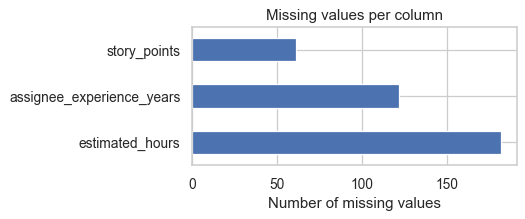

In [4]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_%": (missing / len(df) * 100).round(2),
})
print(missing_table)

fig, ax = plt.subplots(figsize=(6, 2.6))
missing.plot.barh(ax=ax, color="#4c72b0")
ax.set_title("Missing values per column")
ax.set_xlabel("Number of missing values")
plt.tight_layout()
plt.show()

**Observations**
- Three numeric columns have small amounts of missing data: `estimated_hours` (~2.3%), `assignee_experience_years` (~1.5%) and `story_points` (~0.8%).
- All three are effort/experience quantities with skewed distributions, so we impute with the **median** (for `estimated_hours`, the median *within each task category*, since typical effort differs strongly by category).

## 3. Duplicate Records

In [5]:
print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicate task_id:", df["task_id"].duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)
print("After dropping duplicates:", df.shape)
print("Remaining duplicate task_id:", df["task_id"].duplicated().sum())

Exact duplicate rows: 110
Duplicate task_id: 110
After dropping duplicates: (8000, 12)
Remaining duplicate task_id: 0


**Observations**
- 110 exact duplicate rows were found (identical `task_id` and identical field values) — the same tasks recorded twice. They were **dropped**, leaving 8,000 unique tasks.
- After deduplication every `task_id` is unique.

## 4. Inconsistent Data

In [6]:
print("Raw category labels:")
print(df["category"].value_counts().to_string())

Raw category labels:
category
Bug Fix           2165
Feature           1867
Testing           1128
Maintenance        773
Documentation      744
Deployment         697
Research           376
bug fix             32
feature             27
Bug Fix             26
FEATURE             24
Feature             22
BUG FIX             22
TESTING             19
Testing             12
documentation        9
testing              8
maintenance          7
Maintenance          7
Documentation        6
Deployment           5
research             4
MAINTENANCE          4
RESEARCH             4
DEPLOYMENT           4
deployment           3
DOCUMENTATION        3
Research             2


In [7]:
# Normalize category labels: strip whitespace, unify casing
df["category"] = df["category"].str.strip().str.title()
# Restore the canonical two-word label
df["category"] = df["category"].replace({"Bug fix": "Bug Fix"})

# Strip stray whitespace from task descriptions
df["task_description"] = df["task_description"].str.strip()

print("Normalized category labels:")
print(df["category"].value_counts().to_string())

Normalized category labels:
category
Bug Fix          2245
Feature          1940
Testing          1167
Maintenance       791
Documentation     762
Deployment        709
Research          386


In [8]:
# Sanity checks on numerics and dates
checks = {
    "estimated_hours <= 0": (df["estimated_hours"] <= 0).sum(),
    "story_points not in {1,2,3,5,8,13}": (~df["story_points"].dropna().isin([1, 2, 3, 5, 8, 13])).sum(),
    "due_date before created_date": (df["due_date"] < df["created_date"]).sum(),
    "assignee_open_tasks negative": (df["assignee_open_tasks"] < 0).sum(),
}
for name, count in checks.items():
    print(f"{name}: {count}")

estimated_hours <= 0: 0
story_points not in {1,2,3,5,8,13}: 0
due_date before created_date: 0
assignee_open_tasks negative: 0


**Observations**
- `category` contained **inconsistent labels** — lowercase (`bug fix`), uppercase (`BUG FIX`) and trailing-whitespace variants of the same 7 classes. After stripping and unifying casing, exactly 7 clean classes remain.
- Some `task_description` values carried leading/trailing whitespace — stripped.
- All numeric and date sanity checks pass: no non-positive effort estimates, no invalid story points, and every deadline falls on or after the creation date.

## 5. Target & Categorical Distributions — Count Plots

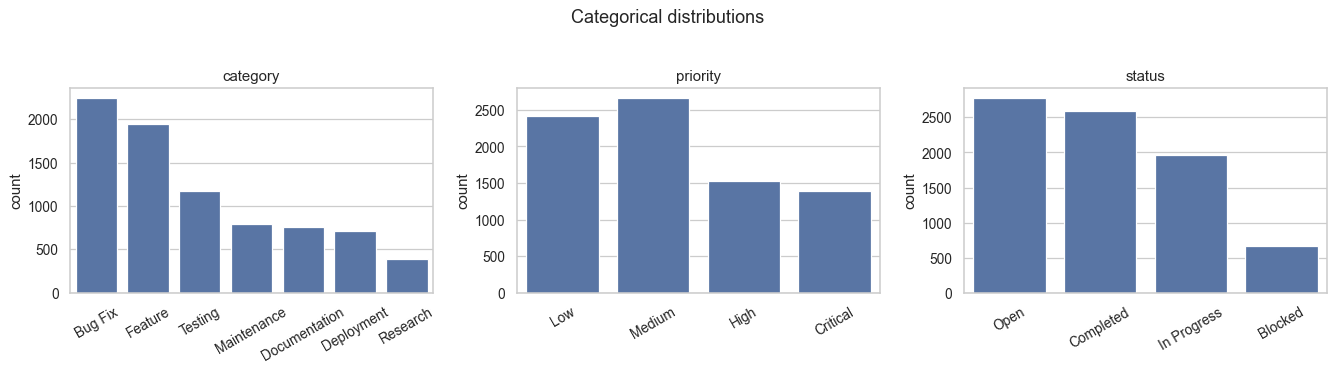

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, order in [
    (axes[0], "category", df["category"].value_counts().index),
    (axes[1], "priority", ["Low", "Medium", "High", "Critical"]),
    (axes[2], "status", df["status"].value_counts().index),
]:
    sns.countplot(data=df, x=col, order=order, color="#4c72b0", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.suptitle("Categorical distributions", y=1.03)
plt.tight_layout()
plt.show()

**Observations**
- **`category` (Week 2 classification target):** Bug Fix (~28%) and Feature (~25%) dominate; Research is the smallest class (~5%) — a stratified split is needed in Week 2.
- **`priority` (Week 3 target):** Medium > Low > High > Critical — mild imbalance, realistic for a task board.
- **`status`:** roughly one third Open, one third Completed; Blocked is rare (~8%).

## 6. Numeric Features — Histograms

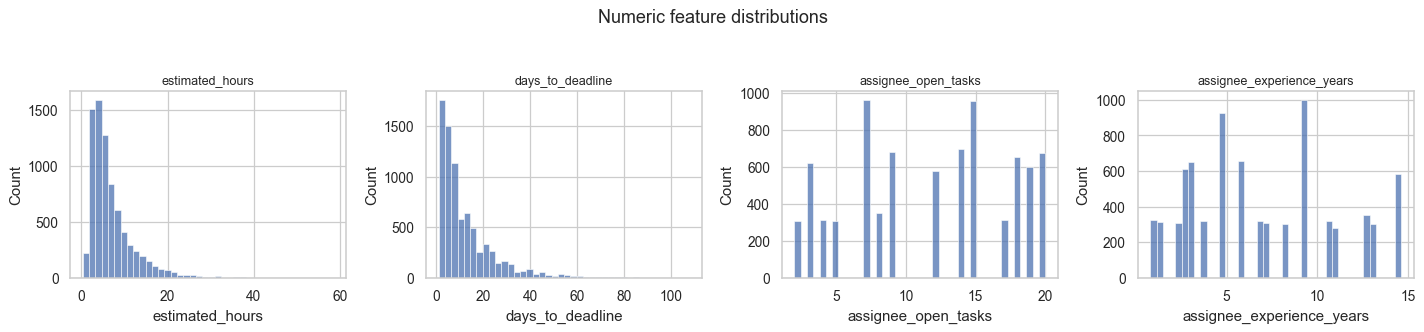

In [10]:
df["days_to_deadline"] = (df["due_date"] - df["created_date"]).dt.days

num_cols = ["estimated_hours", "days_to_deadline", "assignee_open_tasks", "assignee_experience_years"]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col].dropna(), bins=40, color="#4c72b0", ax=ax)
    ax.set_title(col, fontsize=10)
plt.suptitle("Numeric feature distributions", y=1.05)
plt.tight_layout()
plt.show()

**Observations**
- `estimated_hours` is right-skewed (log-normal shaped): most tasks are short, a few need 20+ hours — this supports median imputation.
- `days_to_deadline` (engineered from the two dates) is right-skewed; most deadlines are within ~3 weeks.
- Assignee workload and experience are roughly uniform across the 25 simulated users.

## 7. Correlation Heatmap

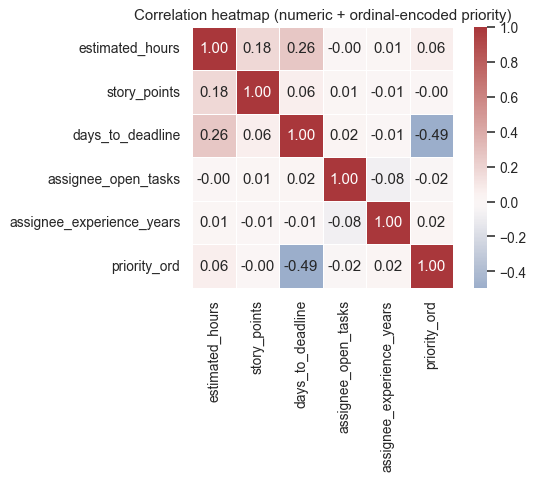

In [11]:
df_corr = df.copy()
df_corr["priority_ord"] = df_corr["priority"].map({"Low": 0, "Medium": 1, "High": 2, "Critical": 3})

corr_cols = ["estimated_hours", "story_points", "days_to_deadline",
             "assignee_open_tasks", "assignee_experience_years", "priority_ord"]
corr = df_corr[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation heatmap (numeric + ordinal-encoded priority)")
plt.tight_layout()
plt.show()

**Observations**
- **`days_to_deadline` has a strong negative correlation with priority** — tighter deadlines mean higher priority, exactly the signal the Week 3 model should exploit.
- `estimated_hours` correlates positively with priority (bigger tasks tend to be rated higher) and moderately with `story_points`, as expected.
- Assignee workload/experience are uncorrelated with priority — they matter for **assignment**, not prioritization.

## 8. Bivariate Analysis — Features vs Targets

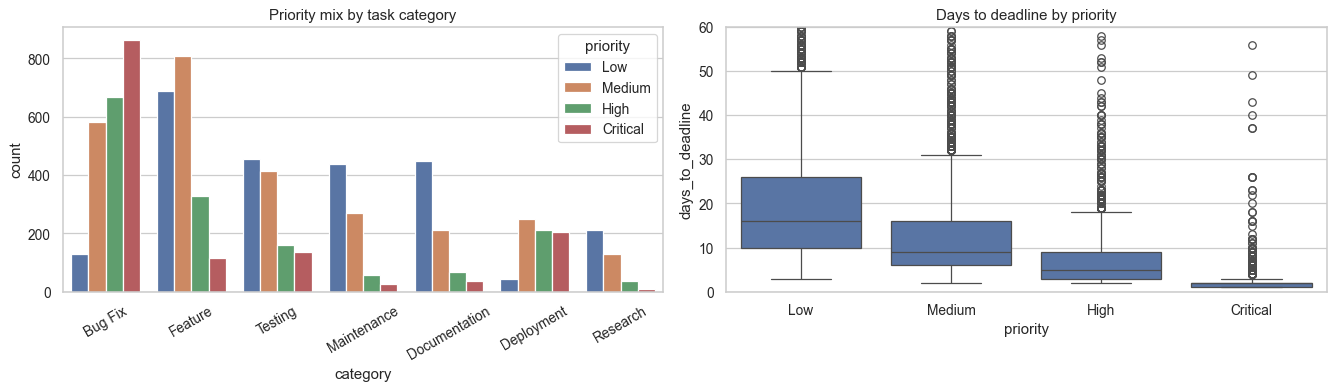

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

prio_order = ["Low", "Medium", "High", "Critical"]
sns.countplot(data=df, x="category", hue="priority", hue_order=prio_order,
              order=df["category"].value_counts().index, ax=axes[0])
axes[0].set_title("Priority mix by task category")
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(data=df, x="priority", y="days_to_deadline", order=prio_order,
            color="#4c72b0", ax=axes[1])
axes[1].set_ylim(0, 60)
axes[1].set_title("Days to deadline by priority")

plt.tight_layout()
plt.show()

**Observations**
- **Bug Fix and Deployment tasks carry a much larger share of High/Critical priorities** — consistent with their tighter deadlines.
- The boxplot confirms the deadline–priority relationship: Critical tasks have a median deadline of only a few days, Low-priority tasks several weeks.

## 9. Data Cleaning — Imputation and Save

In [13]:
# Median imputation (estimated_hours: median within each category)
df["estimated_hours"] = df.groupby("category")["estimated_hours"] \
                          .transform(lambda s: s.fillna(s.median()))
df["assignee_experience_years"] = df["assignee_experience_years"] \
                                    .fillna(df["assignee_experience_years"].median())
df["story_points"] = df["story_points"].fillna(df["story_points"].median())

print("Remaining missing values:", df.isna().sum().sum())
print("Final shape:", df.shape)

Remaining missing values: 0
Final shape: (8000, 13)


In [14]:
import os
os.makedirs("../data/processed", exist_ok=True)
df.to_csv("../data/processed/tasks_clean.csv", index=False)
print("Saved cleaned dataset to data/processed/tasks_clean.csv")

Saved cleaned dataset to data/processed/tasks_clean.csv


## 10. Conclusions

**Cleaning performed**
- Dropped 110 exact duplicate records (8,110 → 8,000 unique tasks)
- Normalized inconsistent `category` labels (casing + whitespace) down to the 7 canonical classes
- Stripped whitespace noise from task descriptions
- Median-imputed `estimated_hours` (per category), `assignee_experience_years` and `story_points` — zero missing values remain
- Engineered `days_to_deadline` from the two date columns

**Key findings for the next stages**
1. `category` is learnable from description text (wording differs clearly by class) but imbalanced — use stratified splits in Week 2.
2. `days_to_deadline` and `estimated_hours` are the strongest priority signals — core features for the Week 3 priority model.
3. Workload fields (`assignee_open_tasks`, experience) are independent of priority — reserve them for the assignment/balancing logic.
4. Task descriptions still contain urgency markers (`URGENT:`, `ASAP -`), punctuation and mixed case — handled next in the NLP preprocessing notebook.

**Deliverable:** `data/processed/tasks_clean.csv` — 8,000 rows × 13 columns, no missing values, consistent labels.